In [3]:
import pandas as pd
import numpy as np


In [4]:
df=pd.read_csv("spam.csv",encoding_errors="replace")

In [5]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.2 KB


In [8]:
df=df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"])

In [9]:
df=df.rename(columns={"v1":"target","v2":"text"})

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [11]:
df["target"]=encoder.fit_transform(df["target"])

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df=df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.shape

(5169, 2)

EDA starts from here 


In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   target  5169 non-null   int64
 1   text    5169 non-null   str  
dtypes: int64(1), str(1)
memory usage: 521.7 KB


In [17]:
import matplotlib.pyplot as plt


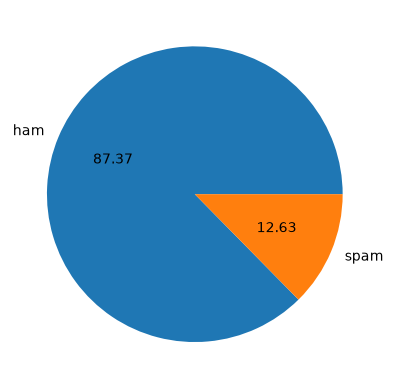

In [18]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [19]:
import nltk
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SOUVIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [20]:
df["num_chars"] = df["text"].apply(len)
df.head()

,target,text,num_chars
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
df['text'].apply(lambda x:len(x.split()))

0       20
1        6
2       28
3       11
4       13
        ..
5567    30
5568     8
5569    10
5570    26
5571     6
Name: text, Length: 5169, dtype: int64

In [22]:
df.iloc[2,:]["text"]

"Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"

In [23]:
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [24]:
df


,target,text,num_chars,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,160,35
5568,0,Will �_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [25]:
df["num_sent"]=df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [26]:
df[df["target"]==0].describe()
df[df["target"]==1].describe()

,target,num_chars,num_words,num_sent
count,653.0,653.000000,653.000000,653.000000
mean,1.0,137.479326,27.679939,2.978560
std,0.0,30.014336,7.014020,1.493185
min,1.0,13.000000,2.000000,1.000000
25%,1.0,131.000000,25.000000,2.000000
50%,1.0,148.000000,29.000000,3.000000
75%,1.0,157.000000,32.000000,4.000000
max,1.0,223.000000,46.000000,9.000000


Data Preprocessing ....
1> handle lower case ....
2> tokenization....
3> removing special characters ....
4> removing stop words and punctuations ....
5> stemming....

In [27]:
df.head()

,target,text,num_chars,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [28]:
df["text"]=df["text"].apply(lambda x: x.lower())


In [29]:
df["text"]

0       go until jurong point, crazy.. available only ...
1                           ok lar... joking wif u oni...
2       free entry in 2 a wkly comp to win fa cup fina...
3       u dun say so early hor... u c already then say...
4       nah i don't think he goes to usf, he lives aro...
                              ...                        
5567    this is the 2nd time we have tried 2 contact u...
5568                will �_ b going to esplanade fr home?
5569    pity, * was in mood for that. so...any other s...
5570    the guy did some bitching but i acted like i'd...
5571                           rofl. its true to its name
Name: text, Length: 5169, dtype: str

In [30]:
from nltk.tokenize import word_tokenize
nltk.download("punkt")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SOUVIK\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [31]:
df["word_tokens"]=df['text'].apply(word_tokenize)

In [32]:
df.head()

,target,text,num_chars,num_words,num_sent,word_tokens
0,0,"go until jurong point, crazy.. available only ...",111,24,2,"[go, until, jurong, point, ,, crazy, .., avail..."
1,0,ok lar... joking wif u oni...,29,8,2,"[ok, lar, ..., joking, wif, u, oni, ...]"
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,37,2,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,0,u dun say so early hor... u c already then say...,49,13,1,"[u, dun, say, so, early, hor, ..., u, c, alrea..."
4,0,"nah i don't think he goes to usf, he lives aro...",61,15,1,"[nah, i, do, n't, think, he, goes, to, usf, ,,..."


In [33]:
import re
df["word_tokens"]=df["word_tokens"].apply(lambda token : [word for word in token if re.match(r'^[a-zA-Z0-9]+$',word)])

In [34]:
df["text"].apply(lambda text: [ word for word in text.split() if re.match(r'[a-zA-Z0-9]+$',word)])

0       [go, until, jurong, available, only, in, bugis...
1                                    [ok, joking, wif, u]
2       [free, entry, in, 2, a, wkly, comp, to, win, f...
3           [u, dun, say, so, early, u, c, already, then]
4       [nah, i, think, he, goes, to, he, lives, aroun...
                              ...                        
5567    [this, is, the, 2nd, time, we, have, tried, 2,...
5568                  [will, b, going, to, esplanade, fr]
5569                          [was, in, mood, for, other]
5570    [the, guy, did, some, bitching, but, i, acted,...
5571                           [its, true, to, its, name]
Name: text, Length: 5169, dtype: object

to remove the punctuations from the df['text] we have to use the strings.punctuations library 

In [35]:
import string 
print("a?" in string.punctuation)
print(string.punctuation)

False
!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [36]:
df

,target,text,num_chars,num_words,num_sent,word_tokens
0,0,"go until jurong point, crazy.. available only ...",111,24,2,"[go, until, jurong, point, crazy, available, o..."
1,0,ok lar... joking wif u oni...,29,8,2,"[ok, lar, joking, wif, u, oni]"
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,37,2,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,0,u dun say so early hor... u c already then say...,49,13,1,"[u, dun, say, so, early, hor, u, c, already, t..."
4,0,"nah i don't think he goes to usf, he lives aro...",61,15,1,"[nah, i, do, think, he, goes, to, usf, he, liv..."
...,...,...,...,...,...,...
5567,1,this is the 2nd time we have tried 2 contact u...,160,35,4,"[this, is, the, 2nd, time, we, have, tried, 2,..."
5568,0,will �_ b going to esplanade fr home?,37,9,1,"[will, b, going, to, esplanade, fr, home]"
5569,0,"pity, * was in mood for that. so...any other s...",57,15,2,"[pity, was, in, mood, for, that, so, any, othe..."
5570,0,the guy did some bitching but i acted like i'd...,125,27,1,"[the, guy, did, some, bitching, but, i, acted,..."


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer()


In [38]:
df.head(0)

,target,text,num_chars,num_words,num_sent,word_tokens


In [39]:
x=df["text"]
y=df["target"]

In [40]:
import matplotlib.pyplot as plt 


In [41]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score

In [42]:
df.head()

,target,text,num_chars,num_words,num_sent,word_tokens
0,0,"go until jurong point, crazy.. available only ...",111,24,2,"[go, until, jurong, point, crazy, available, o..."
1,0,ok lar... joking wif u oni...,29,8,2,"[ok, lar, joking, wif, u, oni]"
2,1,free entry in 2 a wkly comp to win fa cup fina...,155,37,2,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,0,u dun say so early hor... u c already then say...,49,13,1,"[u, dun, say, so, early, hor, u, c, already, t..."
4,0,"nah i don't think he goes to usf, he lives aro...",61,15,1,"[nah, i, do, think, he, goes, to, usf, he, liv..."


In [43]:
x_train, x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [44]:
vectorizer=TfidfVectorizer()
x_train=vectorizer.fit_transform(x_train)
x_test=vectorizer.transform(x_test)

In [45]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 54188 stored elements and shape (4135, 7615)>
  Coords	Values
  (0, 6745)	0.4290636935776824
  (0, 7332)	0.3785517948418016
  (0, 4578)	0.21709512220215293
  (0, 2659)	0.5270656660752561
  (0, 3649)	0.5896391922491296
  (1, 7347)	0.4217170384252327
  (1, 737)	0.489050799272793
  (1, 6738)	0.41109034176033105
  (1, 4860)	0.4738617296637762
  (1, 6711)	0.43525147593537417
  (2, 6711)	0.27218168103953544
  (2, 7212)	0.570691941367055
  (2, 4112)	0.570691941367055
  (2, 4834)	0.26532625399780574
  (2, 4677)	0.3540870024153015
  (2, 6787)	0.2806473272346173
  (3, 2943)	0.13483104122624595
  (3, 7151)	0.19138147395552196
  (3, 1600)	0.19837251636980677
  (3, 5109)	0.22707972001795612
  (3, 7422)	0.11801317081445856
  (3, 3257)	0.18566937638838155
  (3, 5327)	0.2034642016215273
  (3, 4051)	0.18364739755022702
  (3, 5608)	0.2233896012889702
  :	:
  (4133, 2507)	0.3451096683719226
  (4133, 5128)	0.33304460488790644
  (4133, 6063)	0.3

In [46]:
model=MultinomialNB()
model.fit(x_train,y_train)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[3627., 508.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.13,-2.1 ]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 7615)","[[0. ,0. ,0.23,...,0.35,0.28,0. ], [1.56,4.27,0. ,...,0. ,0. ,0.27]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 7615)","[[-9.84,-9.84,-9.64,...,-9.55,-9.6 ,-9.84], [-8.25,-7.53,-9.19,...,-9.19,-9.19,-8.96]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7615


In [47]:
y_pred=model.predict(x_test)

In [48]:
print(accuracy_score(y_test,y_pred))

0.9555125725338491


In [49]:
import pickle

In [50]:
pickle.dump(model,open("spam_model.pkl","wb"))
pickle.dump(vectorizer,open("vectorizer.pkl","wb"))

In [53]:
df.head(0)

,target,text,num_chars,num_words,num_sent,word_tokens


In [63]:
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12596 stored elements and shape (1034, 7615)>